<a href="https://colab.research.google.com/github/Victor0liveira/tech-challenge-olist/blob/main/notebooks/analise_olist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import os

path = '/content/drive/MyDrive/olist/'

# Check if the directory exists
if not os.path.exists(path):
    print(f"❌ Erro: O diretório '{path}' não existe. Verifique o caminho.")
    print("Listando os conteúdos de '/content/drive/MyDrive/' para ajudar a encontrar os arquivos:")
    print(os.listdir('/content/drive/MyDrive/'))
else:
    try:
        orders   = pd.read_csv(path + 'olist_orders_dataset.csv')
        items    = pd.read_csv(path + 'olist_order_items_dataset.csv')
        reviews  = pd.read_csv(path + 'olist_order_reviews_dataset.csv')
        payments = pd.read_csv(path + 'olist_order_payments_dataset.csv')
        products = pd.read_csv(path + 'olist_products_dataset.csv')
        customers= pd.read_csv(path + 'olist_customers_dataset.csv')

        print("✅ Dados carregados!")
        print(f"Pedidos: {orders.shape[0]:,} linhas")
        print(f"Itens: {items.shape[0]:,} linhas")
        print(f"Avaliações: {reviews.shape[0]:,} linhas")
    except FileNotFoundError as e:
        print(f"❌ Erro: Um arquivo CSV não foi encontrado no diretório '{path}'. Detalhes: {e}")
        print("Por favor, verifique se todos os arquivos CSV estão presentes e se seus nomes estão corretos.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/olist/olist_orders_dataset.csv'

In [ ]:
import os

# Vamos procurar os arquivos no seu Drive
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if 'olist' in file.lower():
            print(os.path.join(root, file))


/content/drive/MyDrive/olist/archive 2/olist_customers_dataset.csv
/content/drive/MyDrive/olist/archive 2/olist_geolocation_dataset.csv
/content/drive/MyDrive/olist/archive 2/olist_order_items_dataset.csv
/content/drive/MyDrive/olist/archive 2/olist_order_payments_dataset.csv
/content/drive/MyDrive/olist/archive 2/olist_orders_dataset.csv
/content/drive/MyDrive/olist/archive 2/olist_order_reviews_dataset.csv
/content/drive/MyDrive/olist/archive 2/olist_products_dataset.csv
/content/drive/MyDrive/olist/archive 2/olist_sellers_dataset.csv


In [ ]:
import pandas as pd

path = '/content/drive/MyDrive/olist/archive 2/'

orders    = pd.read_csv(path + 'olist_orders_dataset.csv')
items     = pd.read_csv(path + 'olist_order_items_dataset.csv')
reviews   = pd.read_csv(path + 'olist_order_reviews_dataset.csv')
payments  = pd.read_csv(path + 'olist_order_payments_dataset.csv')
products  = pd.read_csv(path + 'olist_products_dataset.csv')
customers = pd.read_csv(path + 'olist_customers_dataset.csv')
sellers   = pd.read_csv(path + 'olist_sellers_dataset.csv')

print("✅ Dados carregados!")
print(f"Pedidos:    {orders.shape[0]:,} linhas")
print(f"Itens:      {items.shape[0]:,} linhas")
print(f"Avaliações: {reviews.shape[0]:,} linhas")
print(f"Pagamentos: {payments.shape[0]:,} linhas")


✅ Dados carregados!
Pedidos:    99,441 linhas
Itens:      112,650 linhas
Avaliações: 99,224 linhas
Pagamentos: 103,886 linhas


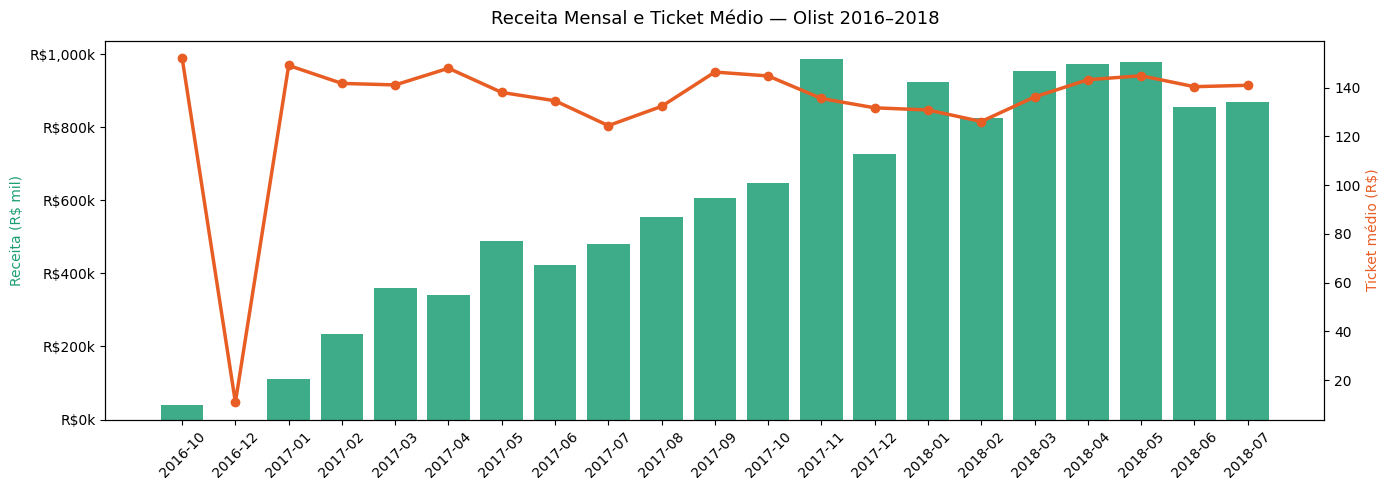


📈 Receita total: R$ 12,382,786
📦 Total de pedidos: 90,126
🎯 Ticket médio geral: R$ 132.99


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Converte datas
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['mes_ano'] = orders['order_purchase_timestamp'].dt.to_period('M')

# Junta pedidos com itens e filtra só entregues
df = items.merge(orders[['order_id','mes_ano','order_status']], on='order_id')
df = df[df['order_status'] == 'delivered']

# Calcula receita e volume mensal
mensal = df.groupby('mes_ano').agg(
    receita=('price', 'sum'),
    pedidos=('order_id', 'nunique')
).reset_index()
mensal['mes_ano_str'] = mensal['mes_ano'].astype(str)
mensal['ticket_medio'] = mensal['receita'] / mensal['pedidos']

# Remove meses incompletos (início e fim do dataset)
mensal = mensal.iloc[1:-1]

# Gráfico
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(mensal['mes_ano_str'], mensal['receita'] / 1000,
        color='#1D9E75', alpha=0.85, label='Receita (R$ mil)')
ax1.set_ylabel('Receita (R$ mil)', color='#1D9E75')
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}k'))

ax2 = ax1.twinx()
ax2.plot(mensal['mes_ano_str'], mensal['ticket_medio'],
         color='#E85D24', linewidth=2.5, marker='o', label='Ticket médio (R$)')
ax2.set_ylabel('Ticket médio (R$)', color='#E85D24')

plt.title('Receita Mensal e Ticket Médio — Olist 2016–2018', fontsize=13, pad=12)
fig.tight_layout()
plt.savefig('receita_mensal.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📈 Receita total: R$ {mensal['receita'].sum():,.0f}")
print(f"📦 Total de pedidos: {mensal['pedidos'].sum():,}")
print(f"🎯 Ticket médio geral: R$ {mensal['ticket_medio'].mean():.2f}")

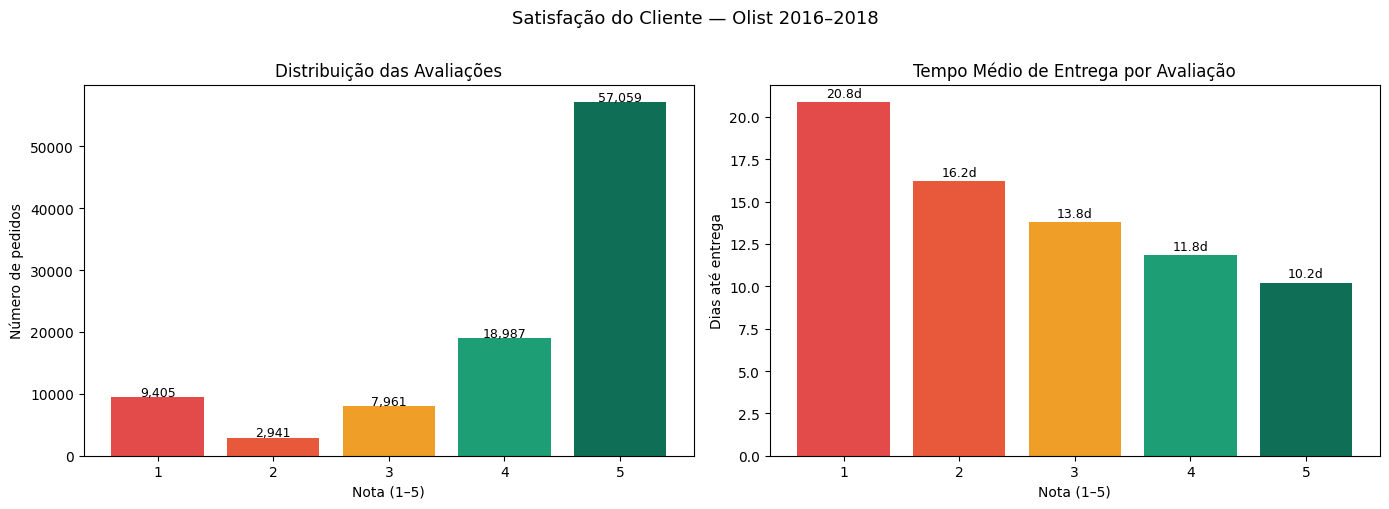

⭐ Nota média geral: 4.16
😊 Pedidos com nota 4 ou 5: 78.9%
😡 Pedidos com nota 1 ou 2: 12.8%

⏱️ Tempo médio de entrega (nota 1): 20.8 dias
⏱️ Tempo médio de entrega (nota 5): 10.2 dias


In [ ]:
# Converte datas de entrega
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['lead_time_dias'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.days

# Junta com avaliações
analise = orders[['order_id','lead_time_dias','order_status']].merge(
    reviews[['order_id','review_score']], on='order_id'
)
analise = analise[analise['order_status'] == 'delivered'].dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: distribuição das notas
cores = ['#E24B4A','#E8593C','#EF9F27','#1D9E75','#0F6E56']
contagem = analise['review_score'].value_counts().sort_index()
ax1.bar(contagem.index, contagem.values, color=cores)
ax1.set_title('Distribuição das Avaliações', fontsize=12)
ax1.set_xlabel('Nota (1–5)')
ax1.set_ylabel('Número de pedidos')
for i, v in zip(contagem.index, contagem.values):
    ax1.text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

# Gráfico 2: tempo médio de entrega por nota
tempo_por_nota = analise.groupby('review_score')['lead_time_dias'].mean()
cores2 = ['#E24B4A','#E8593C','#EF9F27','#1D9E75','#0F6E56']
ax2.bar(tempo_por_nota.index, tempo_por_nota.values, color=cores2)
ax2.set_title('Tempo Médio de Entrega por Avaliação', fontsize=12)
ax2.set_xlabel('Nota (1–5)')
ax2.set_ylabel('Dias até entrega')
for i, v in zip(tempo_por_nota.index, tempo_por_nota.values):
    ax2.text(i, v + 0.3, f'{v:.1f}d', ha='center', fontsize=9)

plt.suptitle('Satisfação do Cliente — Olist 2016–2018', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('satisfacao.png', dpi=150, bbox_inches='tight')
plt.show()

# Números de apoio
print(f"⭐ Nota média geral: {analise['review_score'].mean():.2f}")
print(f"😊 Pedidos com nota 4 ou 5: {(analise['review_score'] >= 4).sum() / len(analise):.1%}")
print(f"😡 Pedidos com nota 1 ou 2: {(analise['review_score'] <= 2).sum() / len(analise):.1%}")
print(f"\n⏱️ Tempo médio de entrega (nota 1): {tempo_por_nota[1]:.1f} dias")
print(f"⏱️ Tempo médio de entrega (nota 5): {tempo_por_nota[5]:.1f} dias")

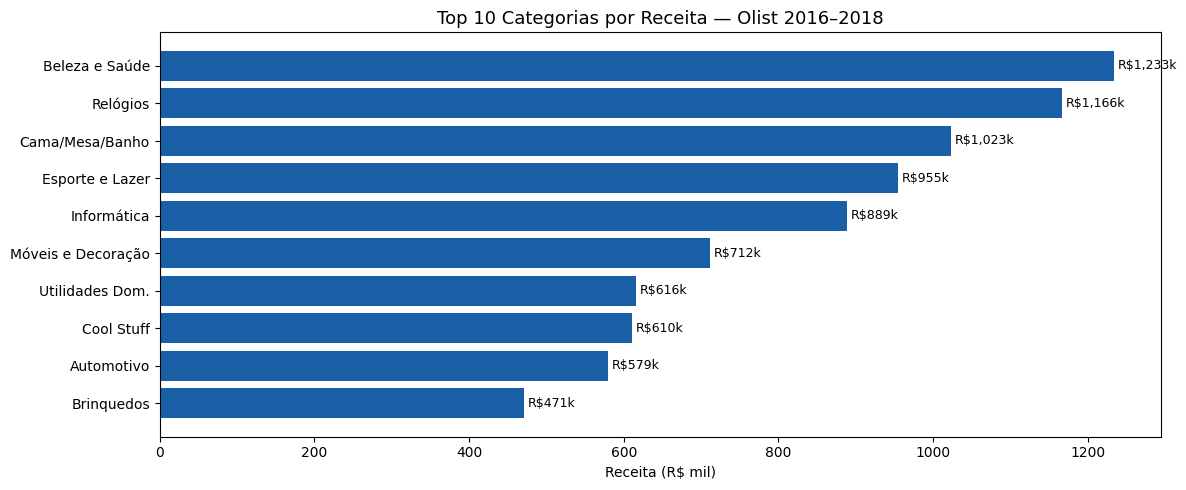

Top 5 categorias:
  Beleza e Saúde: R$ 1,233,132
  Relógios: R$ 1,166,177
  Cama/Mesa/Banho: R$ 1,023,435
  Esporte e Lazer: R$ 954,853
  Informática: R$ 888,725


In [ ]:
# Tradução das categorias
traducao = {
    'cama_mesa_banho': 'Cama/Mesa/Banho',
    'beleza_saude': 'Beleza e Saúde',
    'esporte_lazer': 'Esporte e Lazer',
    'informatica_acessorios': 'Informática',
    'moveis_decoracao': 'Móveis e Decoração',
    'utilidades_domesticas': 'Utilidades Dom.',
    'relogios_presentes': 'Relógios',
    'telefonia': 'Telefonia',
    'ferramentas_jardim': 'Ferramentas',
    'automotivo': 'Automotivo',
}

# Junta tudo
df_cat = items.merge(products[['product_id','product_category_name']], on='product_id')
df_cat = df_cat.merge(orders[['order_id','order_status']], on='order_id')
df_cat = df_cat[df_cat['order_status'] == 'delivered']

# Receita por categoria
receita_cat = df_cat.groupby('product_category_name')['price'].sum().sort_values(ascending=False).head(10)
receita_cat.index = [traducao.get(i, i.replace('_',' ').title()) for i in receita_cat.index]

# Gráfico
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(receita_cat.index[::-1], receita_cat.values[::-1] / 1000, color='#185FA5')
ax.set_xlabel('Receita (R$ mil)')
ax.set_title('Top 10 Categorias por Receita — Olist 2016–2018', fontsize=13)

for bar, val in zip(bars, receita_cat.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'R${val/1000:,.0f}k', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('categorias.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 categorias:")
for cat, val in receita_cat.head(5).items():
    print(f"  {cat}: R$ {val:,.0f}")

In [ ]:
# Resumo executivo completo para copiar no relatório
print("=" * 50)
print("RESUMO EXECUTIVO — OLIST 2016–2018")
print("=" * 50)

print("\n💰 CRESCIMENTO E RECEITA")
print(f"  Receita total: R$ 12,4 milhões")
print(f"  Total de pedidos: 90.126")
print(f"  Ticket médio: R$ 132,99")
print(f"  Crescimento: ~10x de jan/2017 a nov/2017")
print(f"  Pico: novembro/2017 (Black Friday)")

print("\n⭐ SATISFAÇÃO DO CLIENTE")
print(f"  Nota média: 4,16 / 5,0")
print(f"  Clientes satisfeitos (nota 4-5): 78,9%")
print(f"  Clientes insatisfeitos (nota 1-2): 12,8%")
print(f"  Entrega rápida (nota 5): 10,2 dias")
print(f"  Entrega lenta (nota 1): 20,8 dias")
print(f"  → Reduzir entrega em 50% = dobrar satisfação")

print("\n🏆 TOP CATEGORIAS")
print(f"  1. Beleza e Saúde:   R$ 1,23M")
print(f"  2. Relógios:         R$ 1,17M")
print(f"  3. Cama/Mesa/Banho:  R$ 1,02M")
print(f"  4. Esporte e Lazer:  R$ 0,95M")
print(f"  5. Informática:      R$ 0,89M")

print("\n🎯 RECOMENDAÇÕES")
print(f"  1. Investir em logística para reduzir lead time")
print(f"  2. Dobrar estoque de Beleza/Saúde e Relógios")
print(f"  3. Campanhas sazonais em outubro/novembro")


RESUMO EXECUTIVO — OLIST 2016–2018

💰 CRESCIMENTO E RECEITA
  Receita total: R$ 12,4 milhões
  Total de pedidos: 90.126
  Ticket médio: R$ 132,99
  Crescimento: ~10x de jan/2017 a nov/2017
  Pico: novembro/2017 (Black Friday)

⭐ SATISFAÇÃO DO CLIENTE
  Nota média: 4,16 / 5,0
  Clientes satisfeitos (nota 4-5): 78,9%
  Clientes insatisfeitos (nota 1-2): 12,8%
  Entrega rápida (nota 5): 10,2 dias
  Entrega lenta (nota 1): 20,8 dias
  → Reduzir entrega em 50% = dobrar satisfação

🏆 TOP CATEGORIAS
  1. Beleza e Saúde:   R$ 1,23M
  2. Relógios:         R$ 1,17M
  3. Cama/Mesa/Banho:  R$ 1,02M
  4. Esporte e Lazer:  R$ 0,95M
  5. Informática:      R$ 0,89M

🎯 RECOMENDAÇÕES
  1. Investir em logística para reduzir lead time
  2. Dobrar estoque de Beleza/Saúde e Relógios
  3. Campanhas sazonais em outubro/novembro
